## Setup

In [1]:
# ------------------------------------------------------------
# 1. Setup
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import shutil
from google.colab import files
from IPython.display import Image, display

warnings.filterwarnings("ignore")



Mounted at /content/drive


In [2]:
# ------------------------------------------------------------
# 2. File paths
# ------------------------------------------------------------
BUSINESS_JSON_PATH = "/content/drive/MyDrive/yelp/yelp_academic_dataset_business.json"
CHECKIN_JSON_PATH = "/content/drive/MyDrive/yelp/yelp_academic_dataset_checkin.json"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Optional: clear old plot files so only current outputs remain
for old_file in [
    "hours_distribution.png",
    "checkins_distribution.png",
    "hours_vs_checkins.png",
    "region_comparison.png",
    "model_fit.png",
    "nb_model_fit.png"
]:
    old_path = os.path.join(PLOTS_DIR, old_file)
    if os.path.exists(old_path):
        os.remove(old_path)



In [3]:
# ------------------------------------------------------------
# 3. Visual style
# ------------------------------------------------------------
YELP_RED = "#d32323"
YELP_DARK = "#2f2f2f"
YELP_GRID = "#dddddd"
YELP_BG = "#ffffff"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.edgecolor"] = YELP_DARK
plt.rcParams["axes.labelcolor"] = YELP_DARK
plt.rcParams["xtick.color"] = YELP_DARK
plt.rcParams["ytick.color"] = YELP_DARK
plt.rcParams["text.color"] = YELP_DARK
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

def apply_chart_style(ax):
    ax.set_facecolor(YELP_BG)
    ax.grid(True, axis="y", color=YELP_GRID, linewidth=0.8, alpha=0.8)
    ax.grid(False, axis="x")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(YELP_DARK)
    ax.spines["bottom"].set_color(YELP_DARK)

def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.close()



In [4]:
# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------
def calculate_hours(time_range: str) -> float:
    """
    Convert strings like '9:0-17:30' into total open hours.
    Handles overnight hours like '11:0-2:0'.
    """
    if pd.isna(time_range) or str(time_range).strip().lower() in {"none", "", "nan"}:
        return 0.0
    try:
        open_time, close_time = str(time_range).split("-")
        open_hour, open_minute = map(int, open_time.split(":"))
        close_hour, close_minute = map(int, close_time.split(":"))
        open_total = open_hour * 60 + open_minute
        close_total = close_hour * 60 + close_minute
        if close_total < open_total:
            close_total += 24 * 60
        return (close_total - open_total) / 60.0
    except Exception:
        return 0.0

def map_region(state: str) -> str:
    state = str(state).strip().upper()
    west_states = {"AZ", "NV", "CA", "WA", "OR", "HI", "AK"}
    middle_states = {"OH", "WI", "IL", "MI", "IN", "MN", "MO", "IA", "KS", "NE", "ND", "SD"}
    east_states = {
        "PA", "NC", "SC", "NY", "NJ", "MA", "FL", "GA",
        "VA", "MD", "DC", "DE", "CT", "RI", "VT", "NH", "ME"
    }
    canada_east = {"ON", "QC"}
    if state in west_states:
        return "West"
    if state in middle_states:
        return "Middle"
    if state in east_states or state in canada_east:
        return "East"
    return "Other"

def pseudo_r2(model) -> float:
    return 1 - (model.llf / model.llnull)



## Load raw Yelp files

In [5]:
# ------------------------------------------------------------
# 5. Load raw Yelp files
# ------------------------------------------------------------
print("Loading raw Yelp files...")
business_raw = pd.read_json(BUSINESS_JSON_PATH, lines=True)
checkin_raw = pd.read_json(CHECKIN_JSON_PATH, lines=True)
print("Business raw shape:", business_raw.shape)
print("Check-in raw shape:", checkin_raw.shape)



Loading raw Yelp files...
Business raw shape: (150346, 14)
Check-in raw shape: (131930, 2)


## Build analysis-ready tables

In [6]:
# ------------------------------------------------------------
# 6. Build analysis-ready tables
# ------------------------------------------------------------
business = business_raw[[
    "business_id",
    "name",
    "state",
    "stars",
    "review_count",
    "categories"
]].copy()

hours_rows = []
for _, row in business_raw.iterrows():
    hours = row.get("hours", {})
    if pd.isna(hours) or hours is None:
        hours = {}
    hours_rows.append({
        "business_id": row["business_id"],
        "monday": hours.get("Monday"),
        "tuesday": hours.get("Tuesday"),
        "wednesday": hours.get("Wednesday"),
        "thursday": hours.get("Thursday"),
        "friday": hours.get("Friday"),
        "saturday": hours.get("Saturday"),
        "sunday": hours.get("Sunday"),
    })
business_hours = pd.DataFrame(hours_rows)

checkin = checkin_raw.copy()
checkin["checkins"] = checkin["date"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) else 0
)
checkin = checkin[["business_id", "checkins"]].copy()



## Prepare final dataset

In [7]:
# ------------------------------------------------------------
# 7. Prepare final dataset
# ------------------------------------------------------------
days_of_week = [
    "monday", "tuesday", "wednesday",
    "thursday", "friday", "saturday", "sunday"
]

for day in days_of_week:
    business_hours[day] = business_hours[day].apply(calculate_hours)

business_hours["total_hours_per_week"] = business_hours[days_of_week].sum(axis=1)
business_hours = business_hours[["business_id", "total_hours_per_week"]].copy()

checkin_summary = (
    checkin.groupby("business_id", as_index=False)["checkins"]
    .sum()
)

df = business.merge(business_hours, on="business_id", how="left")
df = df.merge(checkin_summary, on="business_id", how="left")
df["total_hours_per_week"] = df["total_hours_per_week"].fillna(0)
df["checkins"] = df["checkins"].fillna(0)
df["stars"] = pd.to_numeric(df["stars"], errors="coerce").fillna(0)
df["review_count"] = pd.to_numeric(df["review_count"], errors="coerce").fillna(0)
df["categories"] = df["categories"].fillna("").astype(str)
df["is_restaurant"] = df["categories"].str.contains(
    "Restaurant", case=False, na=False
).astype(int)
df["region"] = df["state"].apply(map_region)

df = df[
    (df["total_hours_per_week"] > 0) &
    (df["checkins"] > 0)
].copy()

df["hours_stars"] = df["total_hours_per_week"] * df["stars"]
df["hours_reviews"] = df["total_hours_per_week"] * df["review_count"]

print("\nPrepared dataset shape:", df.shape)
print("Total businesses analyzed:", len(df))
print("\nDescriptive statistics:")
print(df[["total_hours_per_week", "checkins", "stars", "review_count"]].describe())




Prepared dataset shape: (106250, 12)
Total businesses analyzed: 106250

Descriptive statistics:
       total_hours_per_week       checkins          stars   review_count
count         106250.000000  106250.000000  106250.000000  106250.000000
mean              61.252769     108.029129       3.661186      55.715162
std               23.625876     353.952463       0.900067     138.160672
min                0.250000       1.000000       1.000000       5.000000
25%               45.000000       6.000000       3.000000       9.000000
50%               59.000000      21.000000       4.000000      19.000000
75%               75.500000      80.000000       4.500000      50.000000
max              167.883333   40109.000000       5.000000    7568.000000


## Negative Binomial models

In [8]:
# ------------------------------------------------------------
# 8. Negative Binomial models
# ------------------------------------------------------------
formula_1 = "checkins ~ total_hours_per_week"

formula_2 = """
checkins ~ total_hours_per_week + stars + review_count + is_restaurant + C(region)
"""

formula_3 = """
checkins ~ total_hours_per_week + stars + review_count + is_restaurant + C(region)
         + hours_stars + hours_reviews
"""

model_1 = sm.GLM.from_formula(
    formula=formula_1,
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

model_2 = sm.GLM.from_formula(
    formula=formula_2,
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

model_3 = sm.GLM.from_formula(
    formula=formula_3,
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print("\n" + "=" * 70)
print("MODEL 1 SUMMARY")
print("=" * 70)
print(model_1.summary())

print("\n" + "=" * 70)
print("MODEL 2 SUMMARY")
print("=" * 70)
print(model_2.summary())

print("\n" + "=" * 70)
print("MODEL 3 SUMMARY")
print("=" * 70)
print(model_3.summary())




MODEL 1 SUMMARY
                 Generalized Linear Model Regression Results                  
Dep. Variable:               checkins   No. Observations:               106250
Model:                            GLM   Df Residuals:                   106248
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.0238e+05
Date:                Mon, 27 Apr 2026   Deviance:                   3.1704e+05
Time:                        20:00:22   Pearson chi2:                 1.09e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.03447
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept      

## Portfolio-ready charts

In [9]:
# ------------------------------------------------------------
# 9. Portfolio-ready charts
# ------------------------------------------------------------

# 9A. Hours distribution
fig, ax = plt.subplots()
sns.histplot(
    df["total_hours_per_week"],
    bins=25,
    color=YELP_RED,
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)
ax.set_title("Most Businesses Operate Within a Similar Weekly Hour Range", pad=12)
ax.set_xlabel("Total Hours Open Per Week")
ax.set_ylabel("Number of Businesses")
apply_chart_style(ax)
save_plot("hours_distribution.png")

# 9B. Check-ins distribution
fig, ax = plt.subplots()
sns.histplot(
    np.log1p(df["checkins"]),
    bins=50,
    color=YELP_RED,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)
ax.set_title("Most Businesses Receive Low Customer Traffic", pad=12)
ax.set_xlabel("Customer Traffic (scaled for readability)")
ax.set_ylabel("Number of Businesses")
apply_chart_style(ax)
save_plot("checkins_distribution.png")

# 9C. Hours vs check-ins
scatter_sample = df.sample(min(20000, len(df)), random_state=42)
fig, ax = plt.subplots()
sns.scatterplot(
    data=scatter_sample,
    x="total_hours_per_week",
    y="checkins",
    alpha=0.2,
    s=8,
    color=YELP_RED,
    edgecolor=None,
    ax=ax
)
sns.regplot(
    data=scatter_sample,
    x="total_hours_per_week",
    y="checkins",
    scatter=False,
    lowess=True,
    color="black",
    line_kws={"linewidth": 2},
    ax=ax
)
ax.set_yscale("log")
ax.set_title("Longer Operating Hours Do Not Strongly Increase Customer Traffic", pad=12)
ax.set_xlabel("Total Hours Open Per Week")
ax.set_ylabel("Customer Traffic (scaled for readability)")
apply_chart_style(ax)
save_plot("hours_vs_checkins.png")

# 9D. Average check-ins by region
region_summary = (
    df.groupby("region", as_index=False)["checkins"]
    .mean()
)
region_order = ["West", "Middle", "East", "Other"]
region_summary["region"] = pd.Categorical(
    region_summary["region"],
    categories=region_order,
    ordered=True
)
region_summary = region_summary.sort_values("region")

fig, ax = plt.subplots()
sns.barplot(
    data=region_summary,
    x="region",
    y="checkins",
    color=YELP_RED,
    ax=ax
)
ax.set_title("Customer Traffic Varies More by Region Than by Hours", pad=12)
ax.set_xlabel("Region")
ax.set_ylabel("Average Customer Traffic")
apply_chart_style(ax)
save_plot("region_comparison.png")

# 9E. Model fit: actual vs predicted
fit_sample = df.sample(min(15000, len(df)), random_state=42).copy()
fit_sample["predicted_checkins"] = model_3.predict(fit_sample)

fig, ax = plt.subplots()
sns.scatterplot(
    data=fit_sample,
    x="checkins",
    y="predicted_checkins",
    alpha=0.18,
    s=10,
    color=YELP_RED,
    edgecolor=None,
    ax=ax
)
max_val = max(
    fit_sample["checkins"].quantile(0.99),
    fit_sample["predicted_checkins"].quantile(0.99)
)
ax.plot(
    [1, max_val],
    [1, max_val],
    linestyle="--",
    color="black",
    linewidth=1.5
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Model Captures Overall Trends but Not Exact Outcomes", pad=12)
ax.set_xlabel("Actual Customer Traffic (scaled)")
ax.set_ylabel("Predicted Customer Traffic (scaled)")
apply_chart_style(ax)
save_plot("model_fit.png")



## Key findings summary

In [10]:
# ------------------------------------------------------------
# 10. Key findings summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)
print(f"\nDataset size: {len(df):,}")
print(f"Model 1 pseudo R²: {pseudo_r2(model_1):.4f}")
print(f"Model 2 pseudo R²: {pseudo_r2(model_2):.4f}")
print(f"Model 3 pseudo R²: {pseudo_r2(model_3):.4f}")

if "total_hours_per_week" in model_1.params:
    print(f"\nHours coefficient (Model 1): {model_1.params['total_hours_per_week']:.4f}")
if "total_hours_per_week" in model_2.params:
    print(f"Hours coefficient (Model 2): {model_2.params['total_hours_per_week']:.4f}")
if "total_hours_per_week" in model_3.params:
    print(f"Hours coefficient (Model 3): {model_3.params['total_hours_per_week']:.4f}")
if "is_restaurant" in model_2.params:
    print(f"Restaurant coefficient (Model 2): {model_2.params['is_restaurant']:.4f}")

print("\nRegion summary:")
print(region_summary.to_string(index=False))




KEY FINDINGS SUMMARY

Dataset size: 106,250
Model 1 pseudo R²: 0.0031
Model 2 pseudo R²: 0.1235
Model 3 pseudo R²: 0.1236

Hours coefficient (Model 1): 0.0079
Hours coefficient (Model 2): 0.0135
Hours coefficient (Model 3): 0.0109
Restaurant coefficient (Model 2): 0.1774

Region summary:
region   checkins
  West 130.587975
Middle 115.009068
  East  91.550888
 Other 123.289200


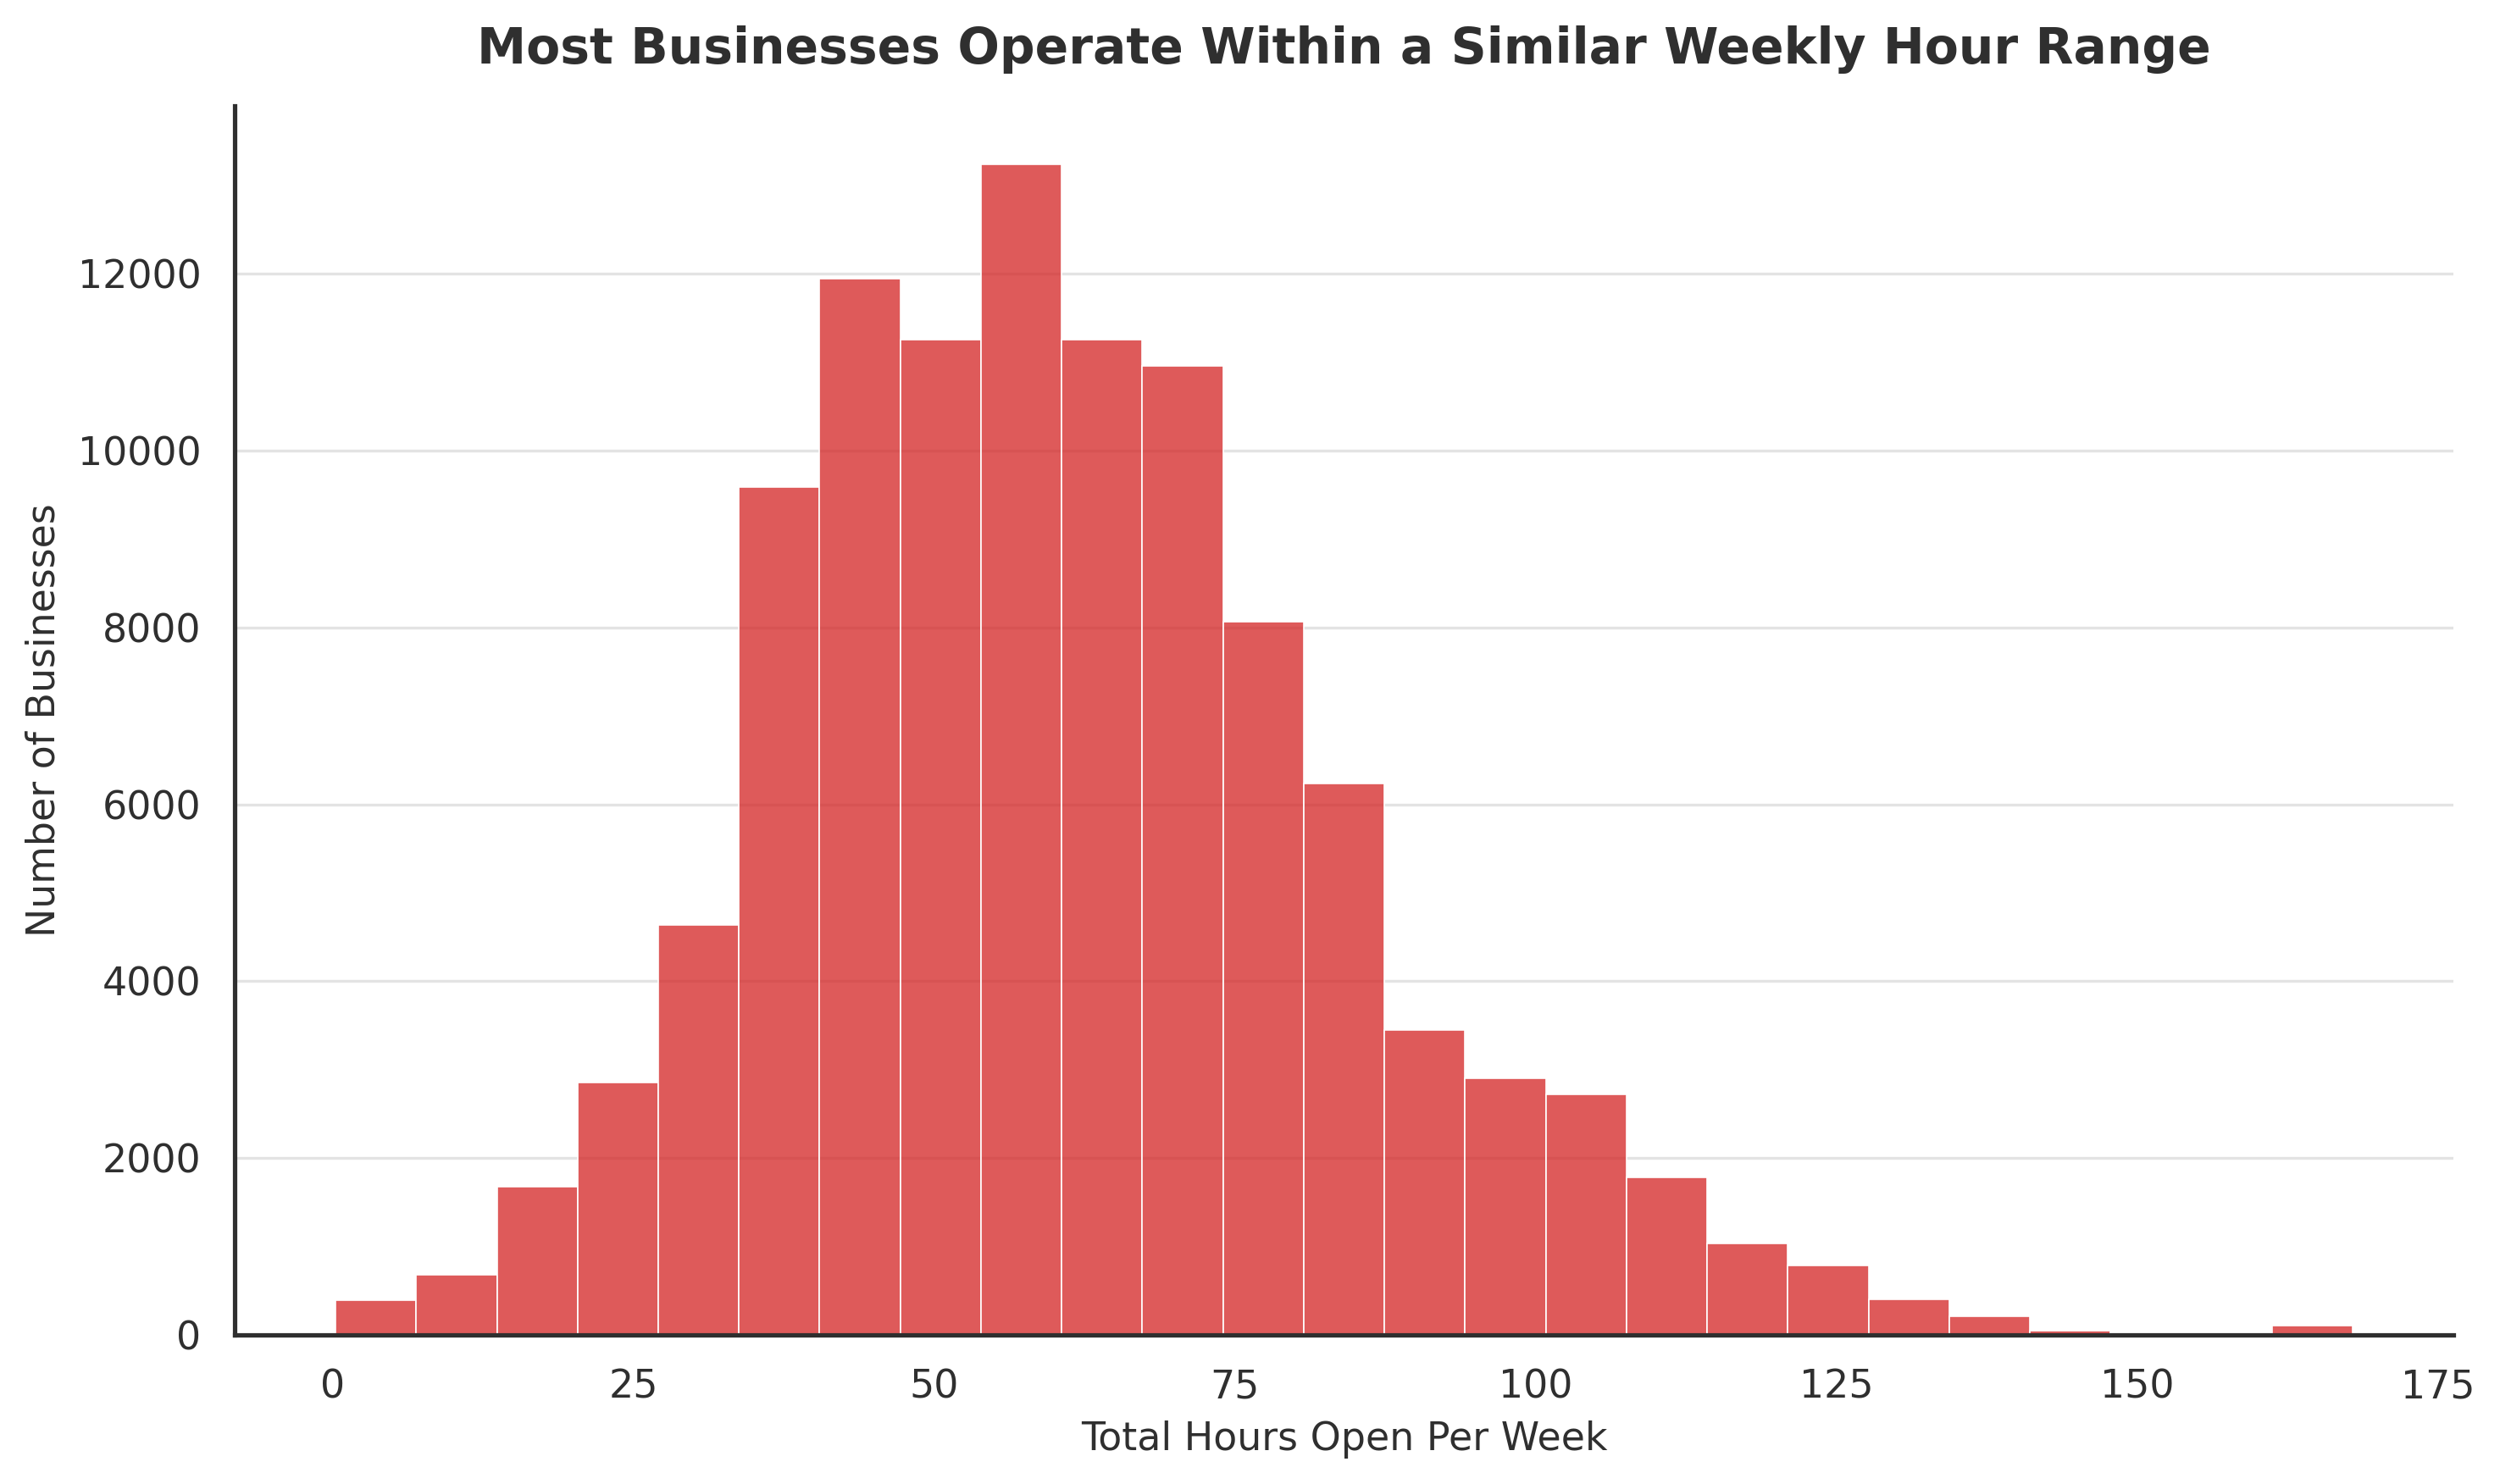

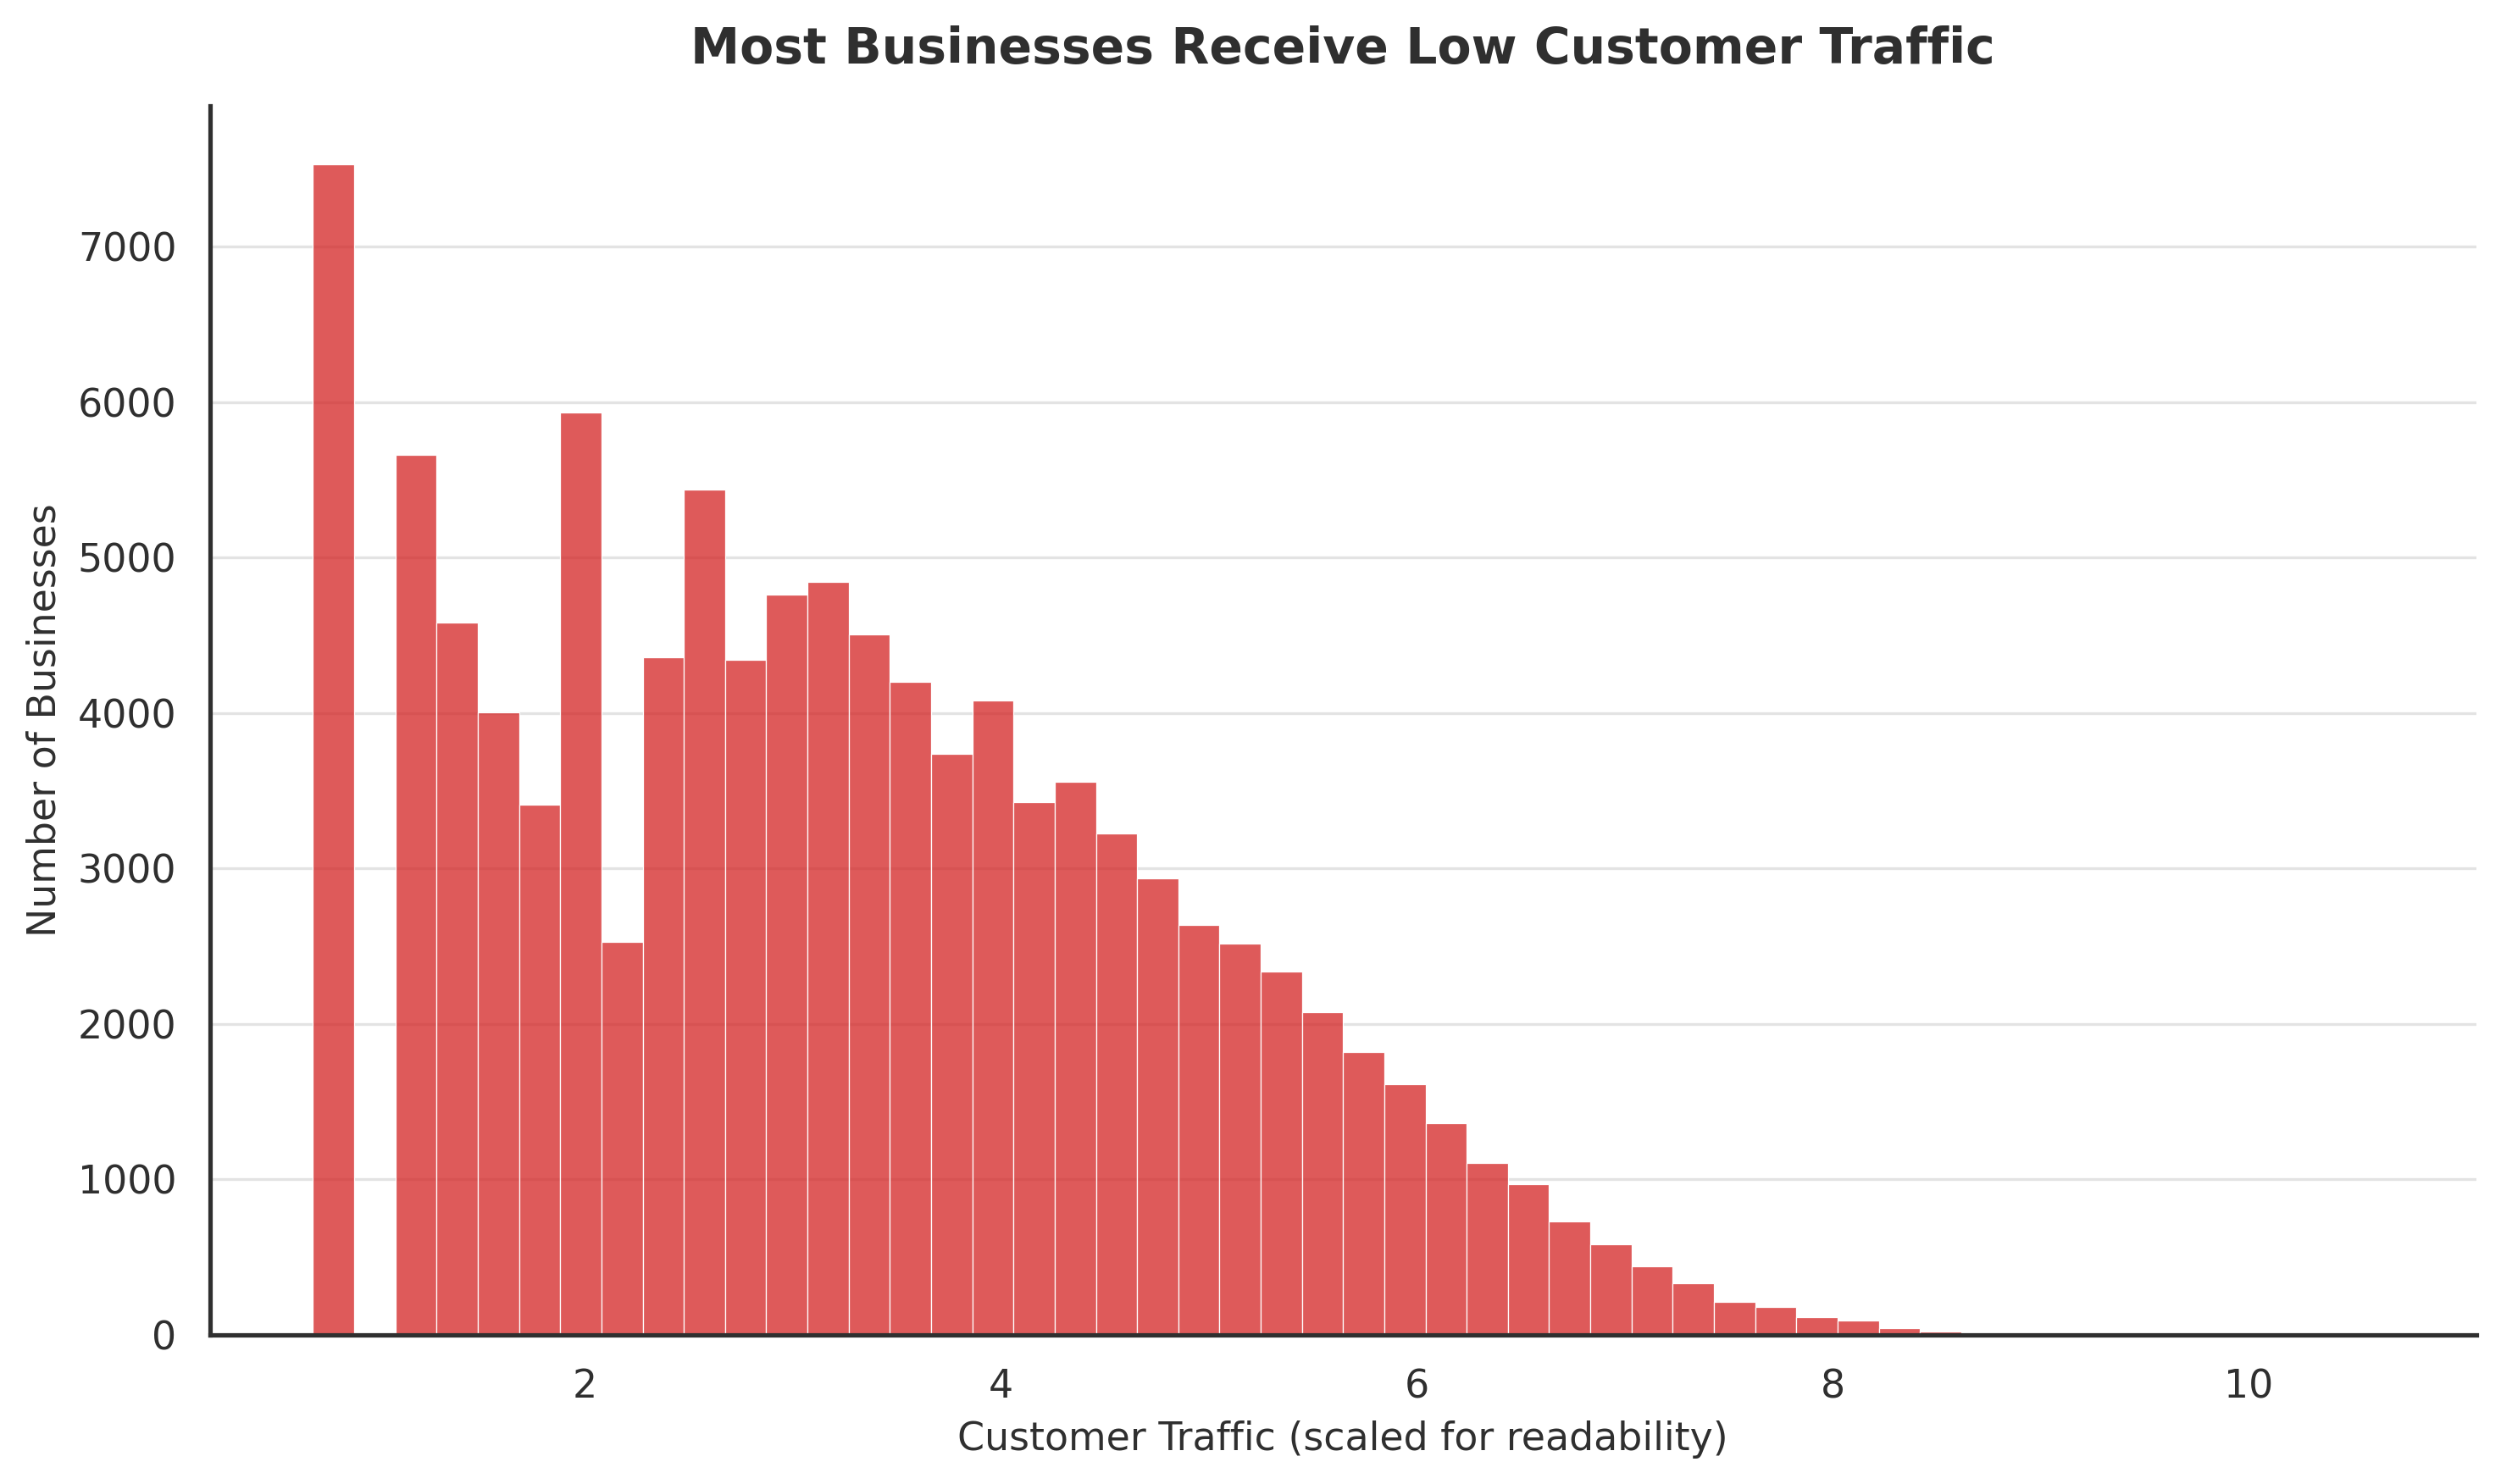

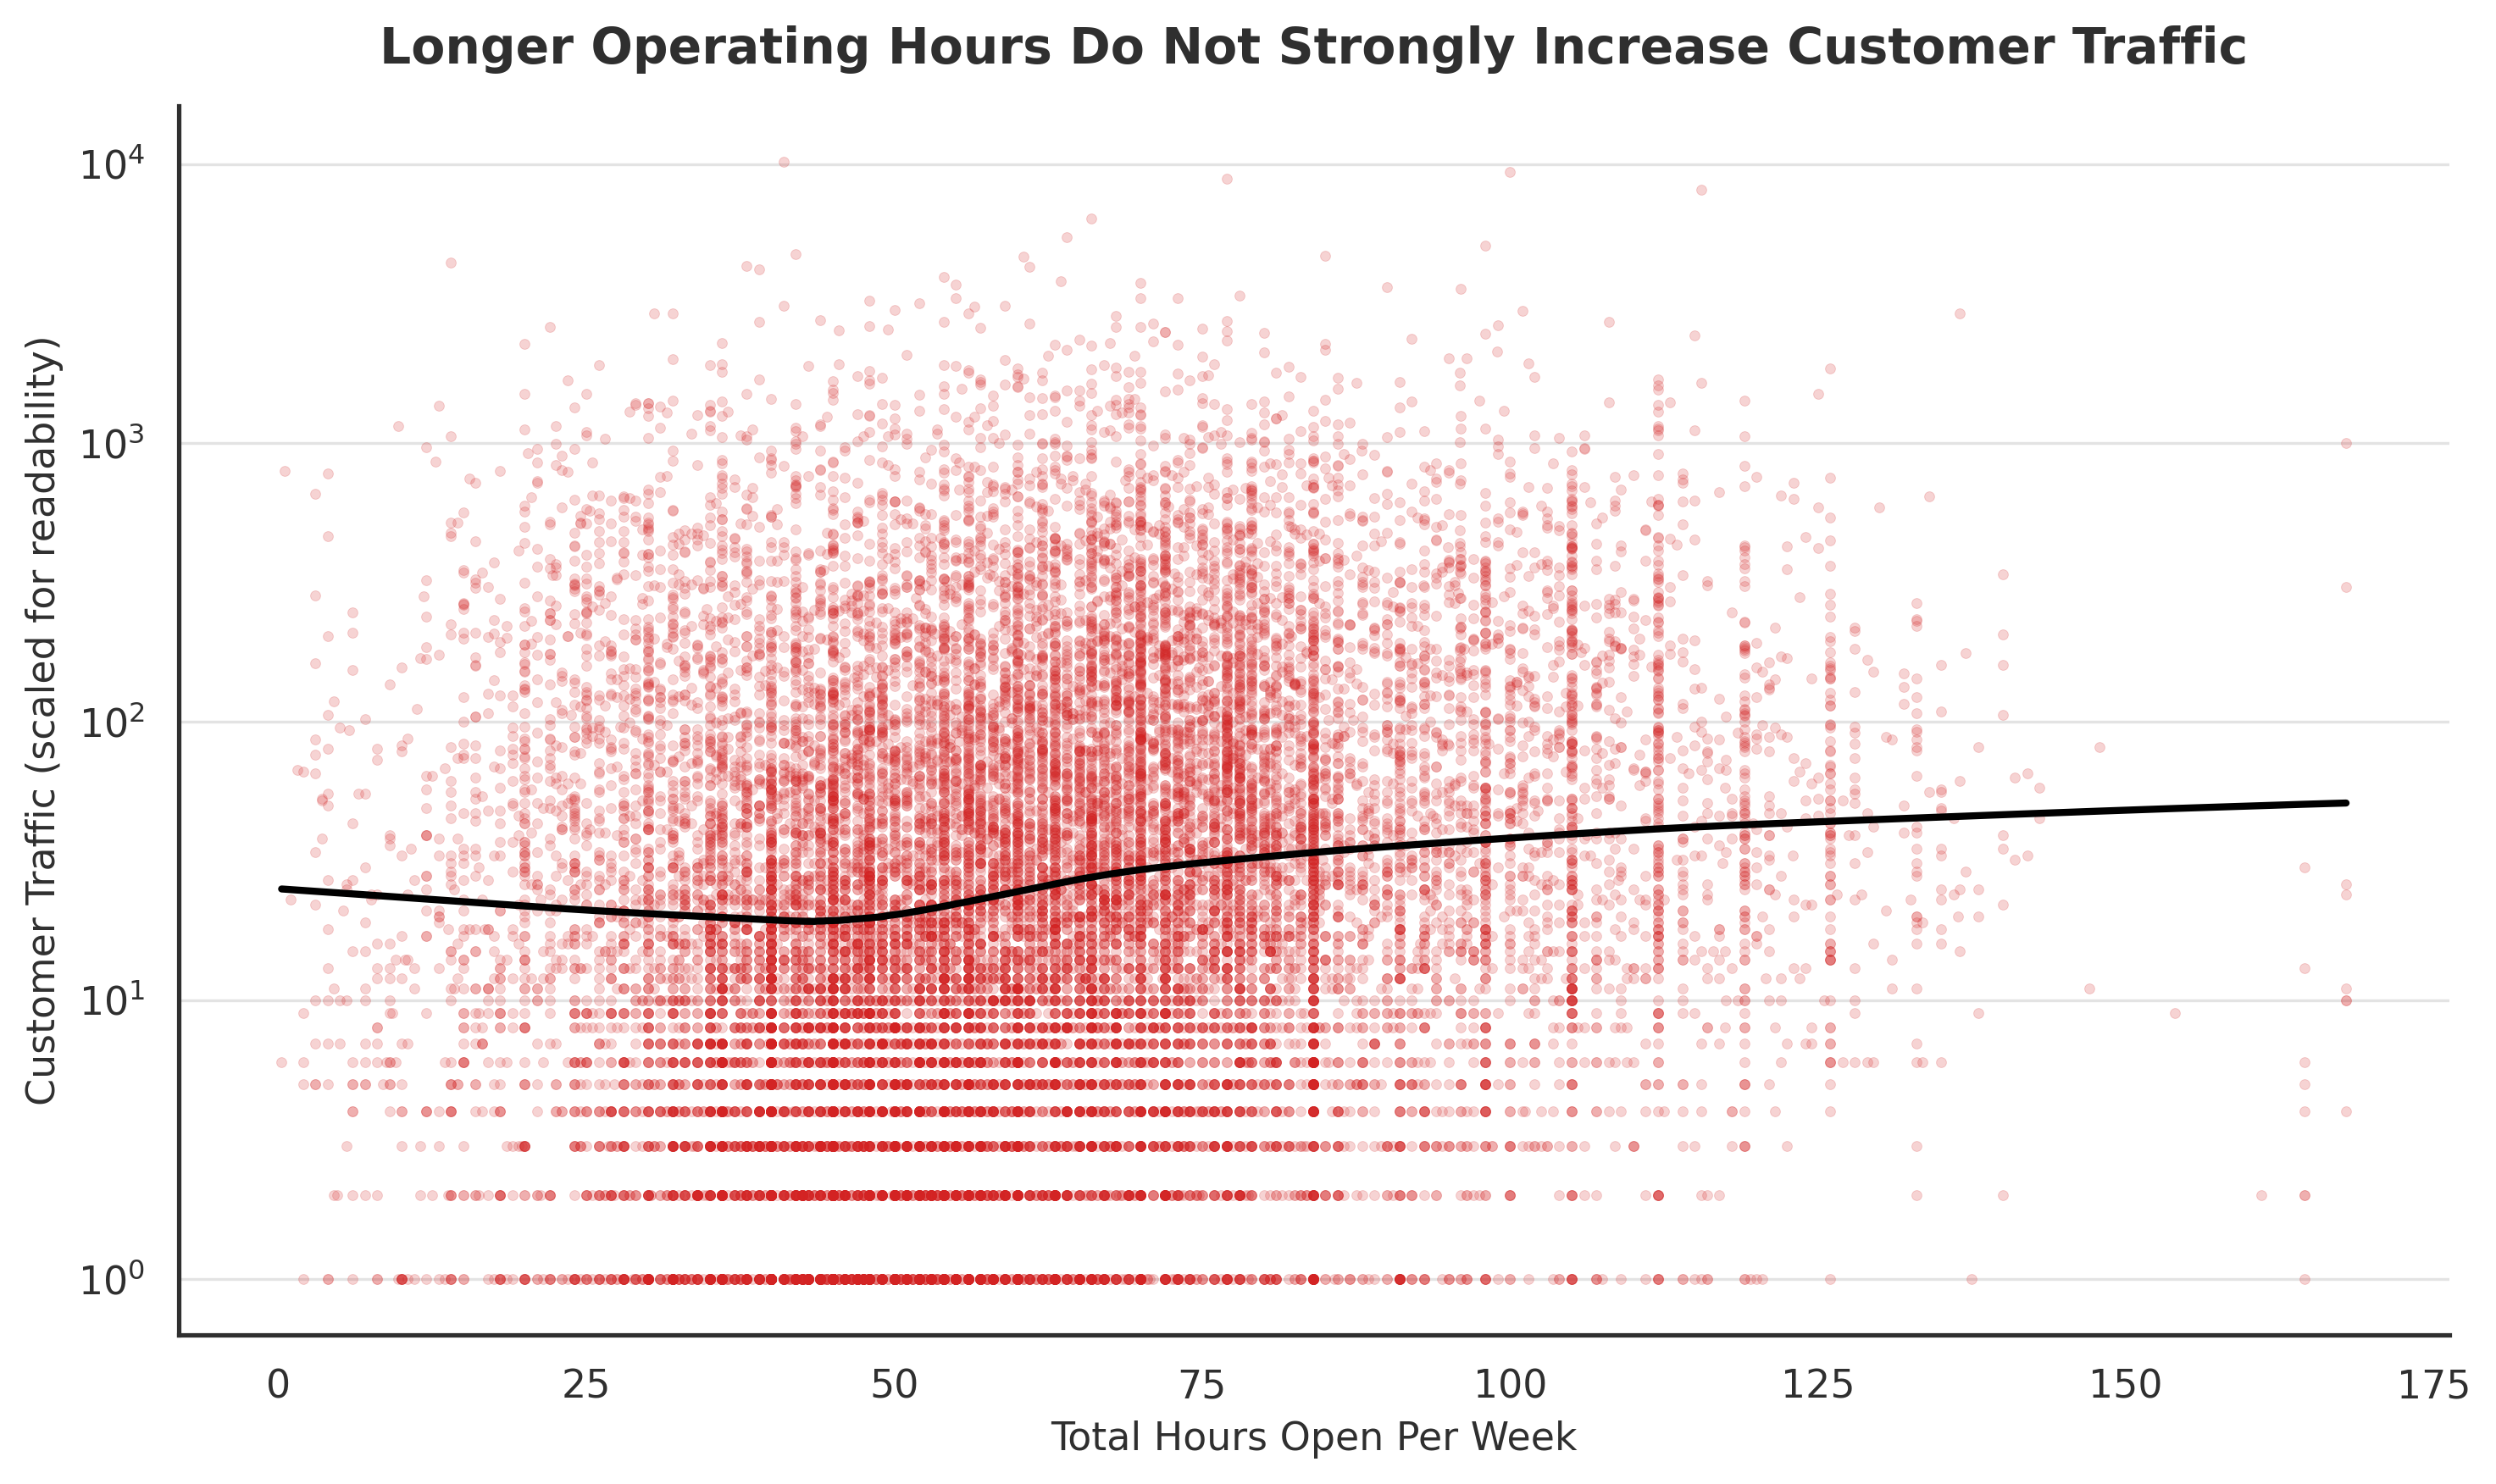

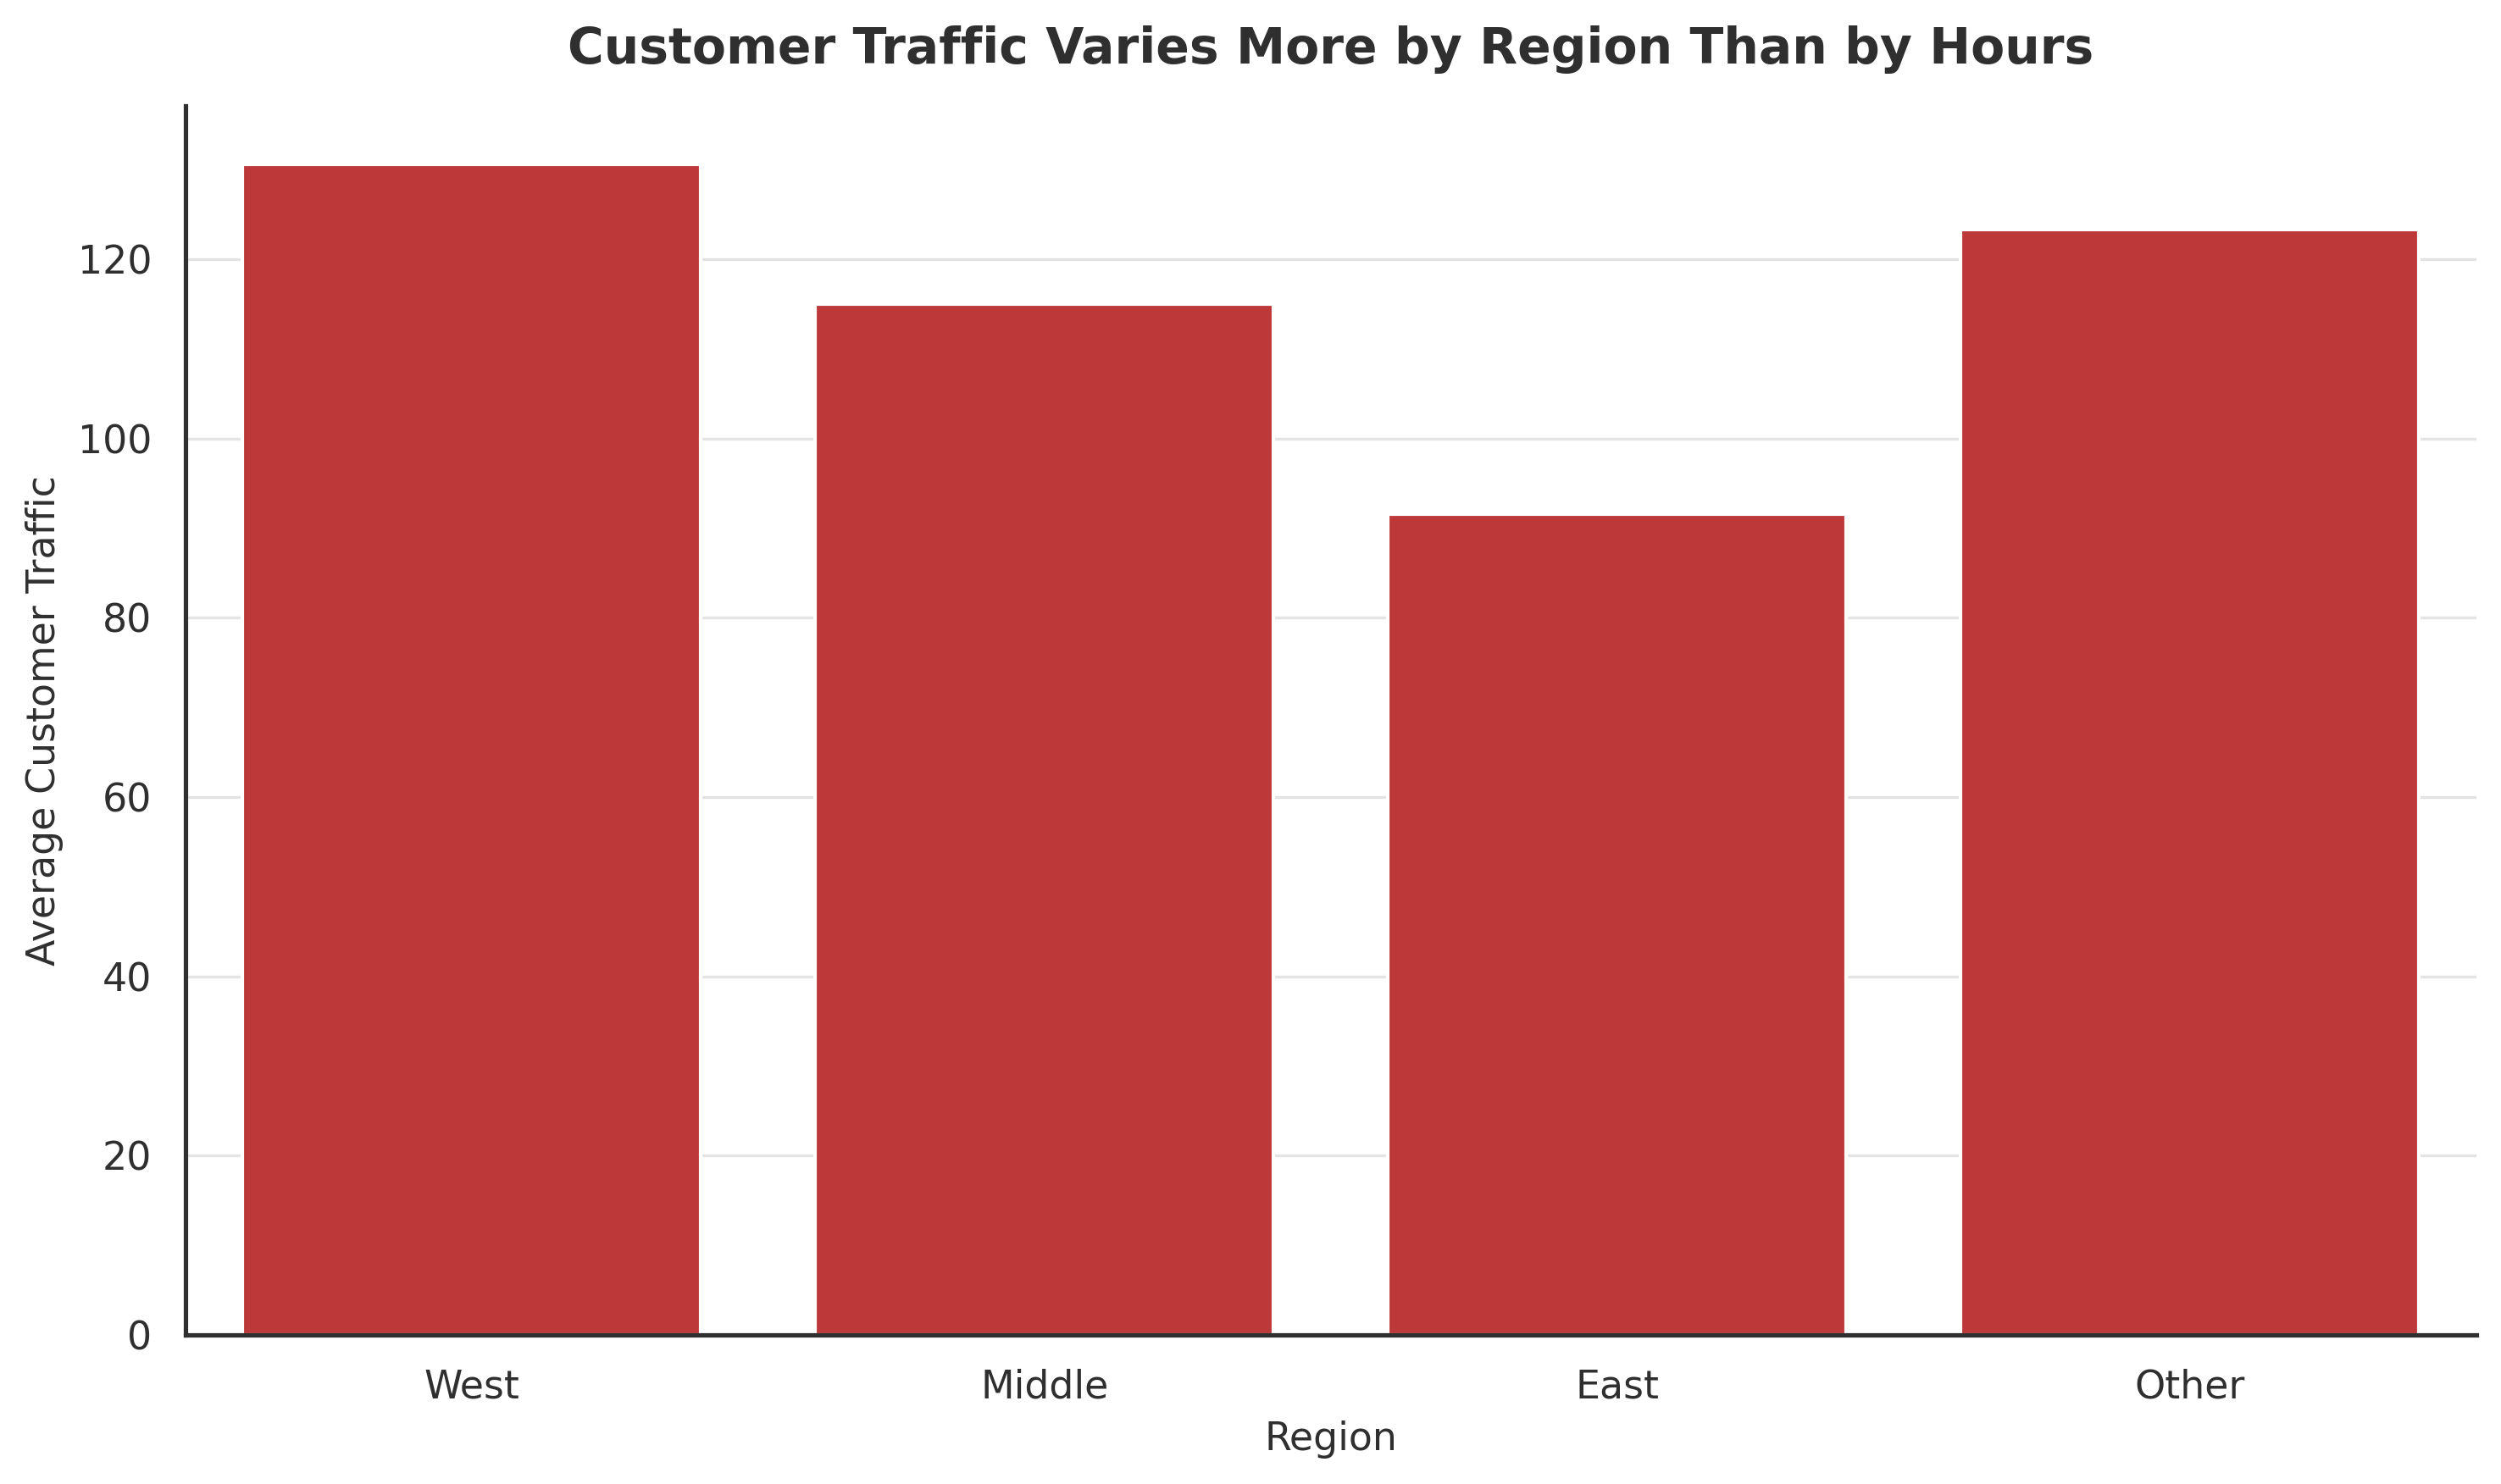

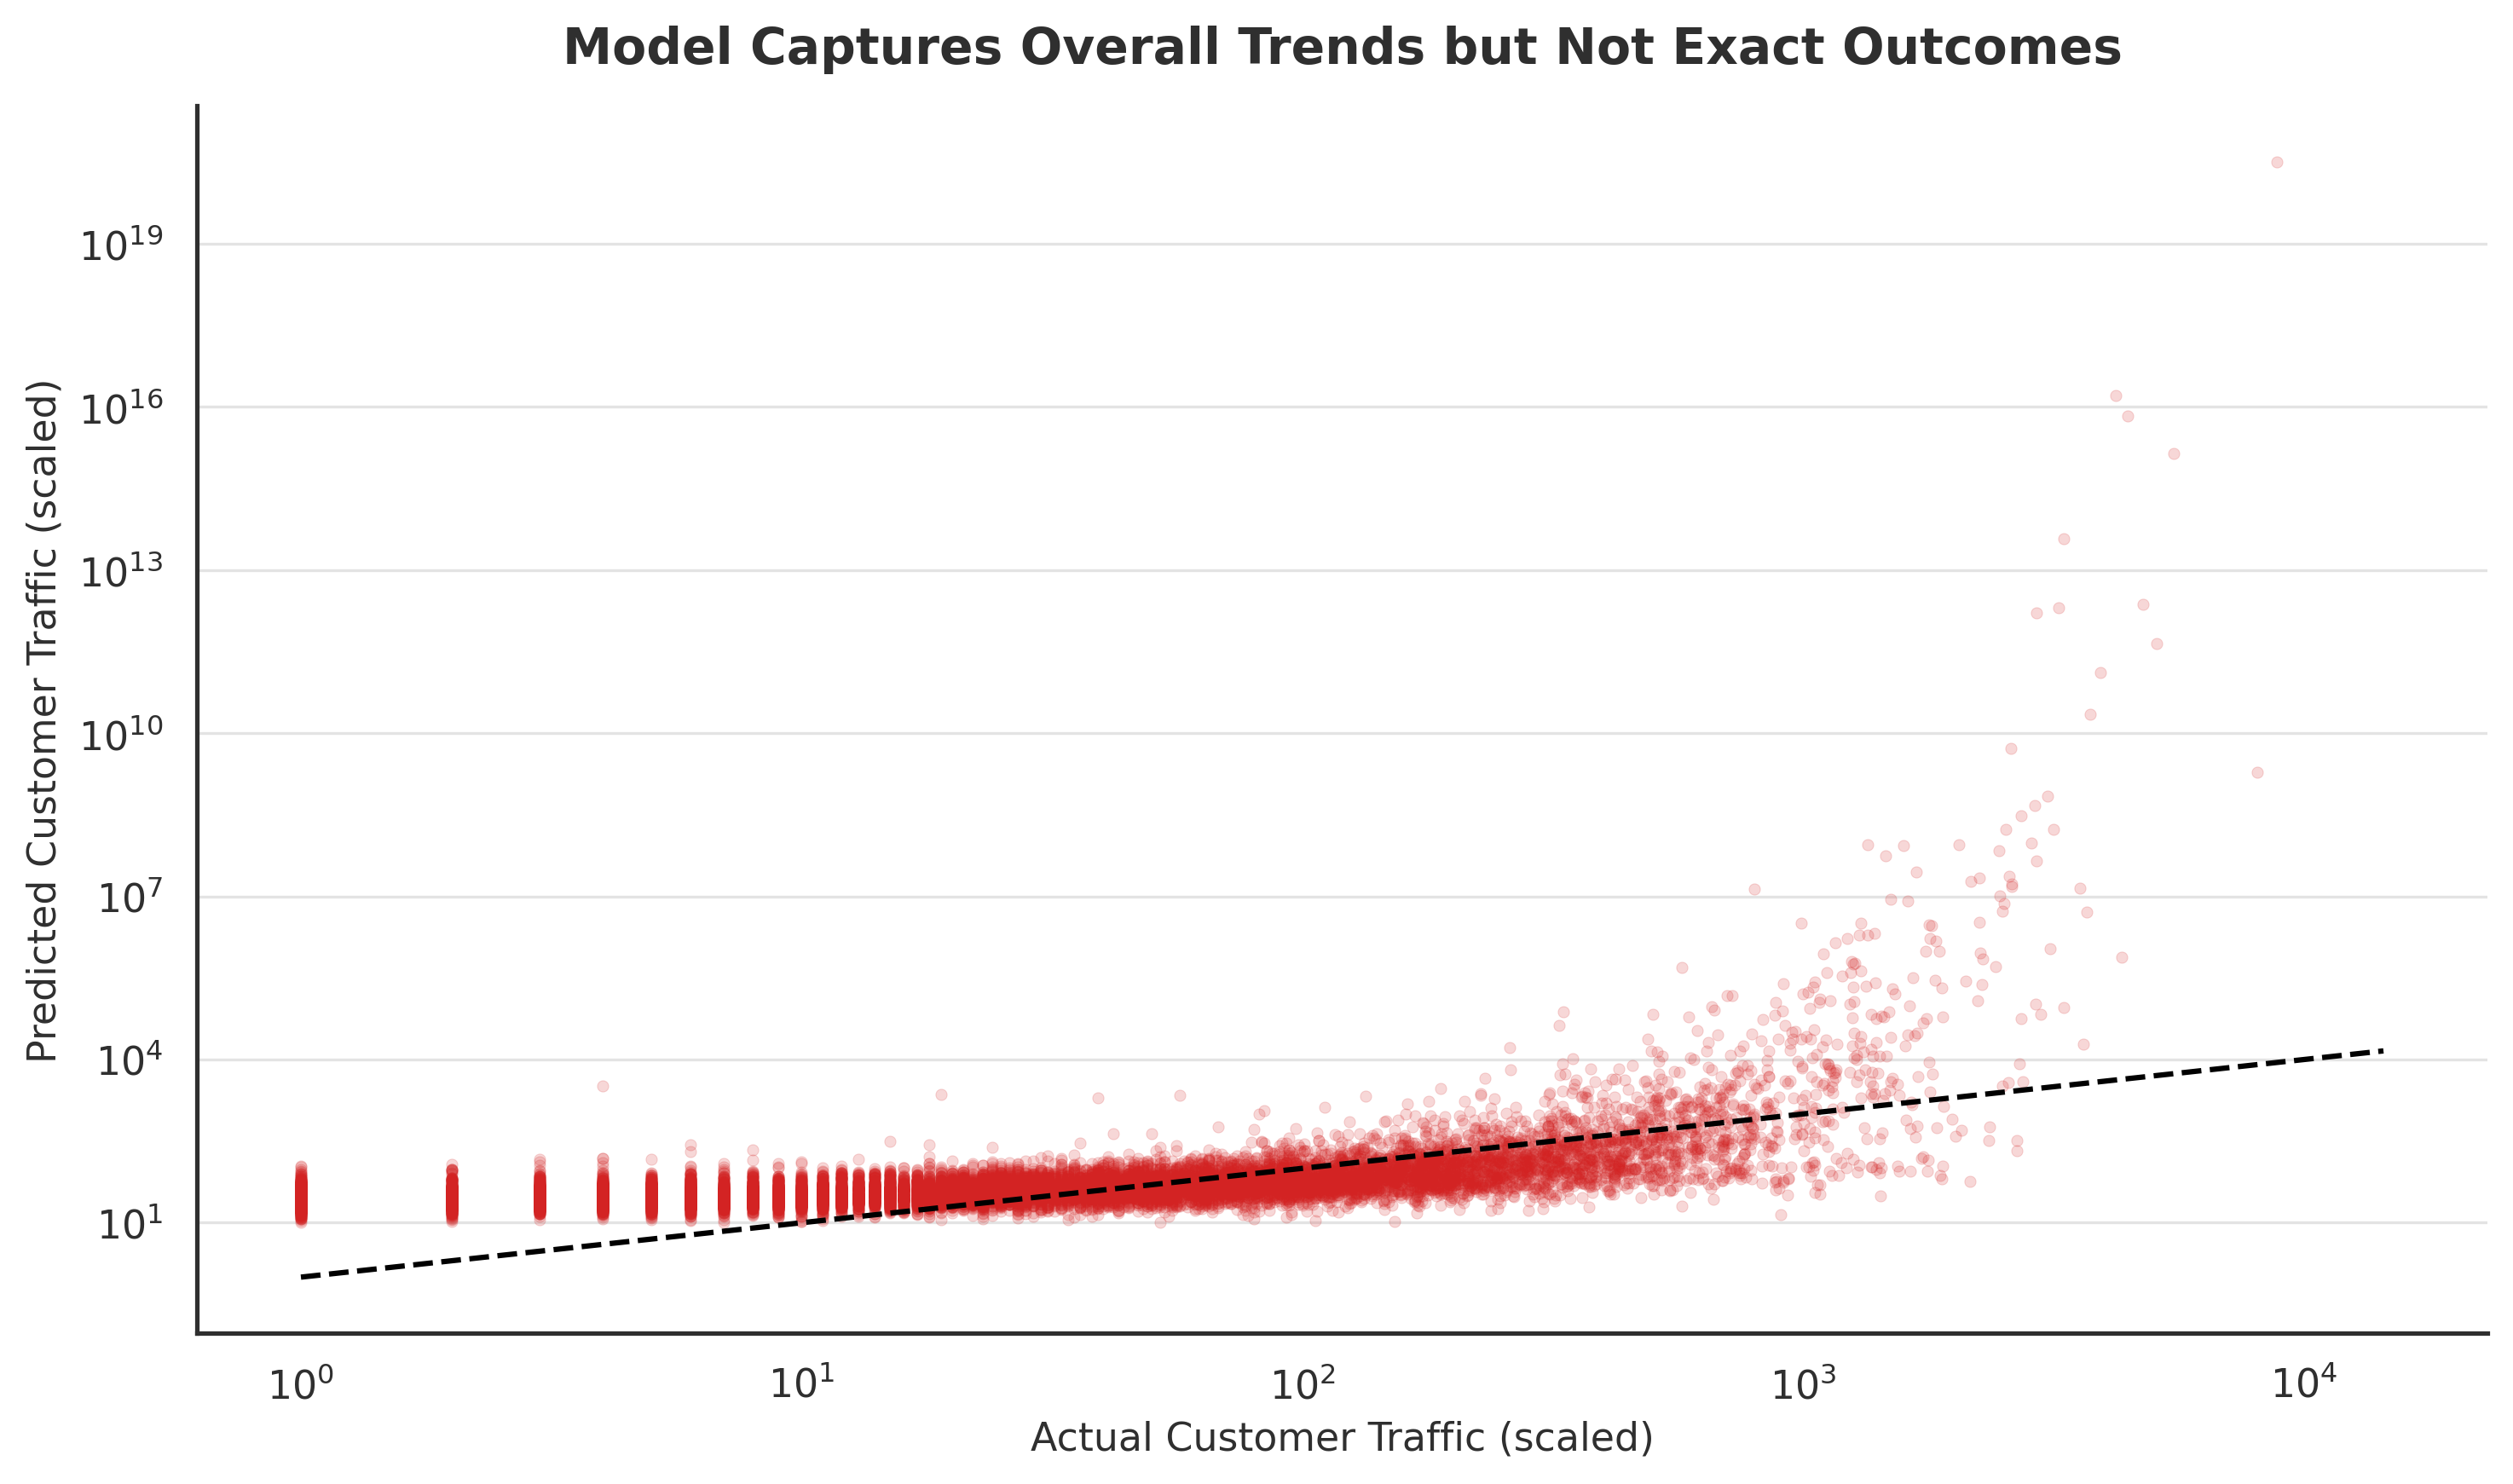

In [15]:
# ------------------------------------------------------------
# 11. Preview charts
# ------------------------------------------------------------
for file_name in [
    "hours_distribution.png",
    "checkins_distribution.png",
    "hours_vs_checkins.png",
    "region_comparison.png",
    "model_fit.png"
]:
    display(Image(filename=os.path.join(PLOTS_DIR, file_name)))

